# **Cognition and Computation - Handwritten German Alphabet**

UniPd - Data Science (2025/2026)



In [1]:
%%capture
def get_dbn_library():
  files = ["DBN.py", "RBM.py"]
  repository_url = "https://raw.githubusercontent.com/flavio2018/Deep-Belief-Network-pytorch/master/"
  for file in files:
    ! wget -O {file} {repository_url}{file}

get_dbn_library()

In [2]:
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import scipy.cluster as cluster
import sklearn.preprocessing
import torch
import torchvision as tv
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
from sklearn.metrics import confusion_matrix

import kagglehub
import os

from DBN import DBN

In [3]:
print(torch.cuda.is_available())
device=torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

True
cuda


## **Introduction**

This project investigates how a Deep Belief Network (DBN) learns to recognize handwritten letters from the German alphabet using a dataset of standardized grayscale character images. The model is trained to extract hierarchical representations from raw pixel inputs, enabling the study of how visual features evolve across layers.

To analyze the learned representations, linear readout classifiers are applied at different levels of the network to assess whether letter classes become more separable in deeper layers. Clustering techniques are also used to explore how distinct letter categories emerge within the hidden feature space.

Model performance is evaluated through confusion matrices to examine classification accuracy and patterns of errors. Finally, the robustness of the DBN is tested by analyzing its vulnerability to adversarial perturbations, providing insight into the stability and limitations of its learned representations.

In [4]:
#import dataset from Kaggle
path = kagglehub.dataset_download("thomassedlmeyr/german-character-recognition-dataset")
print("Path to dataset files:", path)

csv_train=os.path.join(path, "train.csv")
csv_test=os.path.join(path, "test.csv")
df_train=pd.read_csv(csv_train)
df_test=pd.read_csv(csv_test)

df_train = df_train.rename(columns={"!": "label"})
df_test = df_test.rename(columns={"!": "label"})

100%|██████████| 168M/168M [00:00<00:00, 213MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thomassedlmeyr/german-character-recognition-dataset/versions/1


/tmp/ipython-input-1580765201.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train=pd.read_csv(csv_train)
/tmp/ipython-input-1580765201.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test=pd.read_csv(csv_test)


In [5]:
#ensure all labels are strings
train_labels = np.sort(df_train["label"].astype(str).unique())
test_labels  = np.sort(df_test["label"].astype(str).unique())

print(f"Labels ({len(train_labels)}): {train_labels}")

Labels (82): ['!' '$' '&' '(' ')' '+' '0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '<' '>'
 '?' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q'
 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i'
 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'z' '~'
 'ß' 'α' 'β' 'π' 'φ' '€' '∑' '√' '∞' '∫']


The dataset consists of 282,472 grayscale images of size 40 × 40 pixels, representing 82 distinct German characters, digits, and mathematical symbols, however, for this project, only lowercase letters are considered for simplicity. Even though the dataset is about the german alphabet, unfortunately, it does not contain umlaut characters such as ä, ö, or ü, so, additionally to lowercase characters, ß is considered.

In [6]:
classes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j',
           'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't',
           'u', 'v','w', 'x', 'y', 'z','ß']

df_train = df_train[df_train['label'].isin(classes)].reset_index(drop=True)
df_test  = df_test[df_test['label'].isin(classes)].reset_index(drop=True)

found 27 labels: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'ß']


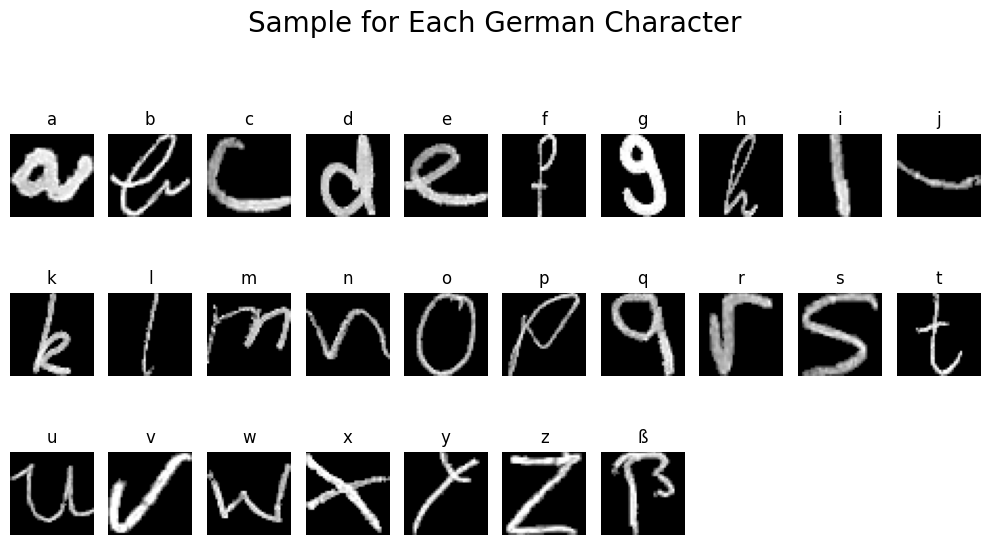

In [7]:
print(f"found {len(classes)} labels: {classes}")

n_labels = len(classes)
cols = 10
rows = int(np.ceil(n_labels / cols))

plt.figure(figsize=(cols * 1, rows * 2))
plt.suptitle("Sample for Each German Character", fontsize=20)

for i, label in enumerate(classes):
    indices_for_label = df_train.index[
        df_train["label"].astype(str) == label
    ].to_numpy()

    idx = indices_for_label[0]

    img_flat = df_train.loc[idx].drop("label").values.astype(np.float32)
    img = img_flat.reshape(40, 40)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [8]:
y_train = df_train["label"].values.astype(str)
y_test = df_test["label"].values.astype(str)

#normalizing pixel cols [0,1]
X_train = df_train.drop("label", axis=1) / 255.0
X_test = df_test.drop("label", axis=1) / 255.0

label_to_idx = {ch: i for i, ch in enumerate(classes)}
y_train_idx = np.array([label_to_idx[x] for x in y_train])
y_test_idx = np.array([label_to_idx[x] for x in y_test])

#from numpy arrays to torch tensors
train_input = torch.tensor(X_train.values, dtype=torch.float32)
train_target = torch.tensor(y_train_idx, dtype=torch.long)

test_input = torch.tensor(X_test.values, dtype=torch.float32)
test_target = torch.tensor(y_test_idx, dtype=torch.long)

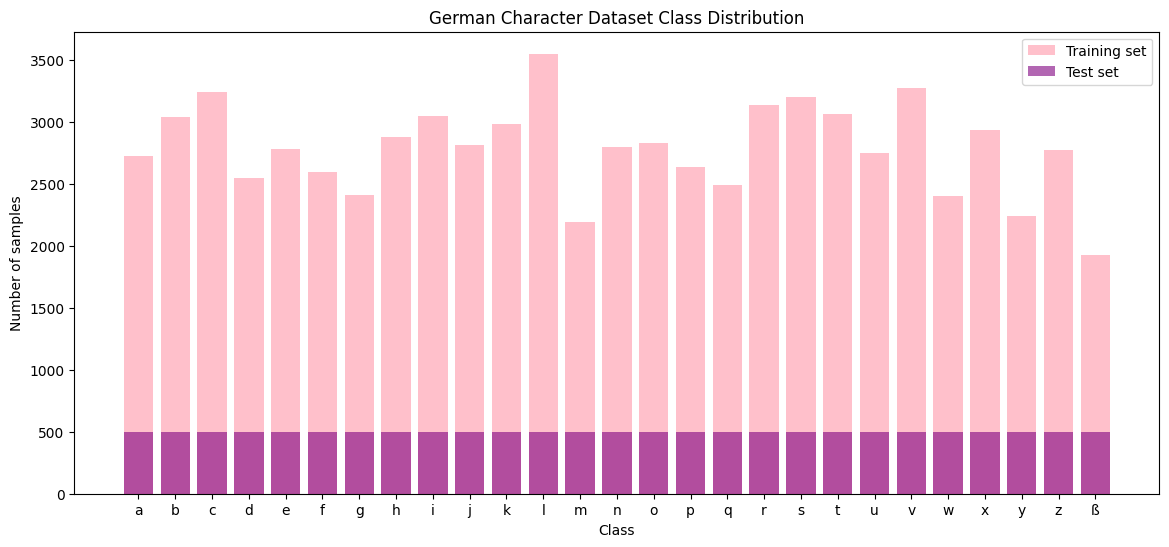

In [9]:
#samples per class in training set
train_counts = [np.sum(y_train == cls) for cls in classes]

#samples per class in test set
test_counts = [np.sum(y_test == cls) for cls in classes]

#training distribution
plt.figure(figsize=(14,6))
plt.bar(classes, train_counts, color='pink', label='Training set')
plt.bar(classes, test_counts, color='purple', alpha=0.6, label='Test set')
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("German Character Dataset Class Distribution")
plt.legend()
plt.show()

In [10]:
distribution_df = pd.DataFrame({
    "Class": classes,
    "Train Samples": train_counts,
    "Test Samples": test_counts
})

print(distribution_df)

   Class  Train Samples  Test Samples
0      a           2721           500
1      b           3042           500
2      c           3239           500
3      d           2546           500
4      e           2785           500
5      f           2599           500
6      g           2411           500
7      h           2875           500
8      i           3044           500
9      j           2813           500
10     k           2986           500
11     l           3550           500
12     m           2194           500
13     n           2795           500
14     o           2828           500
15     p           2637           500
16     q           2490           500
17     r           3133           500
18     s           3197           500
19     t           3062           500
20     u           2745           500
21     v           3272           500
22     w           2400           500
23     x           2936           500
24     y           2238           500
25     z    

The training set is slightly imbalanced: the number of samples per class varies between 1,929 (ß) and 3,550 (l). Meanwhile, the class distribution shows that the test set is perfectly balanced, with exactly 500 samples per class for all 27 characters

## **Model training**

For the DBN model, since the input images are 40×40 pixels instead of 28×28, the number of visible units was increased accordingly and the learning rate reduced compared to the model showed during the labs.

In [11]:
# Define DBN
dbn = DBN(
    visible_units=40*40,
    hidden_units=[400, 650, 800],
    k=1,
    learning_rate=0.05,
    learning_rate_decay=False,
    initial_momentum=0.5,
    final_momentum=0.95,
    weight_decay=0.0001,
    xavier_init=False,
    increase_to_cd_k=False,
    use_gpu=True
)

# Training parameters
num_epochs = 50
batch_size = 80

# Train the DBN
dbn.train_static(
    train_input.clone(),
    train_target.clone(),
    num_epochs,
    batch_size
)

--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.4217     |0.3640       |641.6638   |95.8549     |
|20    |1.3031     |0.3242       |606.5184   |89.0934     |
|30    |1.2704     |0.3132       |598.6854   |88.7015     |
|40    |1.2544     |0.3052       |601.6891   |89.4604     |
|50    |1.2452     |0.3031       |599.1617   |89.5898     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.4905     |0.1571       |227.4711   |24.1006     |
|20    |1.3329     |0.1389       |214.6079   |22.8112     |
|30    |1.3098     |0.1338       |213.7651   |22.1720     |
|40    |1.2961     |0.1331       |212.3013   |22.0527     |
|50    |1.2908     |0.1315       |212.0454   |22.1428     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |0.8397     |0.1539       |290.7549   |36.9329     |
|20    |0.6599     |0.0927       |238.43

The training results show stable and consistent learning across all three RBM layers. In each layer, the average reconstruction error decreases steadily over the 50 epochs, indicating successful feature learning. The gradients decrease smoothly over time, suggesting stable convergence without signs of instability.

In [12]:
def get_weights(dbn, layer):
  return dbn.rbm_layers[layer].W.cpu().numpy()

def apply_threshold(weights, threshold=0):  #might want to apply a threshold to discard very small weights
  return weights * (abs(weights) > threshold)

def apply_min_max_scaler(learned_weights):
  original_shape = learned_weights.shape
  min_max_scaler = sklearn.preprocessing.MinMaxScaler()
  min_max_scaled_learned_weights = min_max_scaler.fit_transform(learned_weights.ravel().reshape(-1,1))
  min_max_scaled_learned_weights = min_max_scaled_learned_weights.reshape(original_shape)
  return min_max_scaled_learned_weights

def plot_layer_receptive_fields(weights):
  num_subplots = 100
  n_rows_cols = int(math.sqrt(num_subplots))
  fig, axes = plt.subplots(n_rows_cols, n_rows_cols, sharex=True, sharey=True, figsize=(10, 10))
  for i in range(num_subplots):
    row = i % n_rows_cols
    col = i // n_rows_cols
    axes[row, col].imshow(weights[i,:].reshape((40,40)), cmap=plt.cm.gray)

To better understand how the DBN processes input images, it is possible visualize the features learned at each hidden layer. These visualizations reveal the type of information captured at different depths of the network gaining insight into how the network transforms pixels into features.


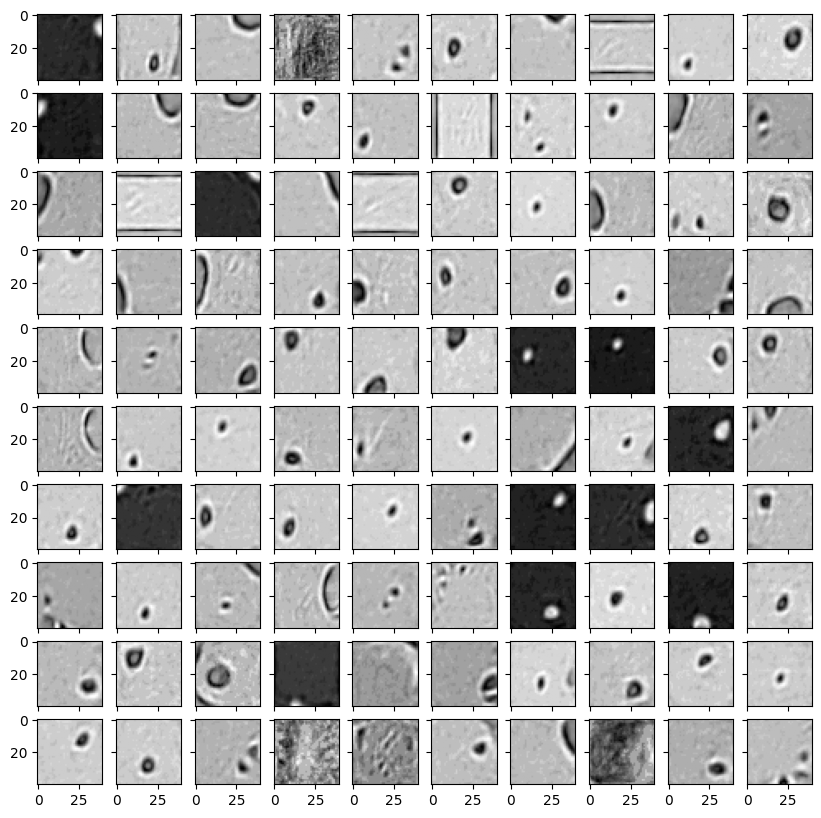

In [13]:
w1 = get_weights(dbn, layer=0)
w1 = apply_threshold(w1, 0.1)
w1 = apply_min_max_scaler(w1)

plot_layer_receptive_fields(w1.T)

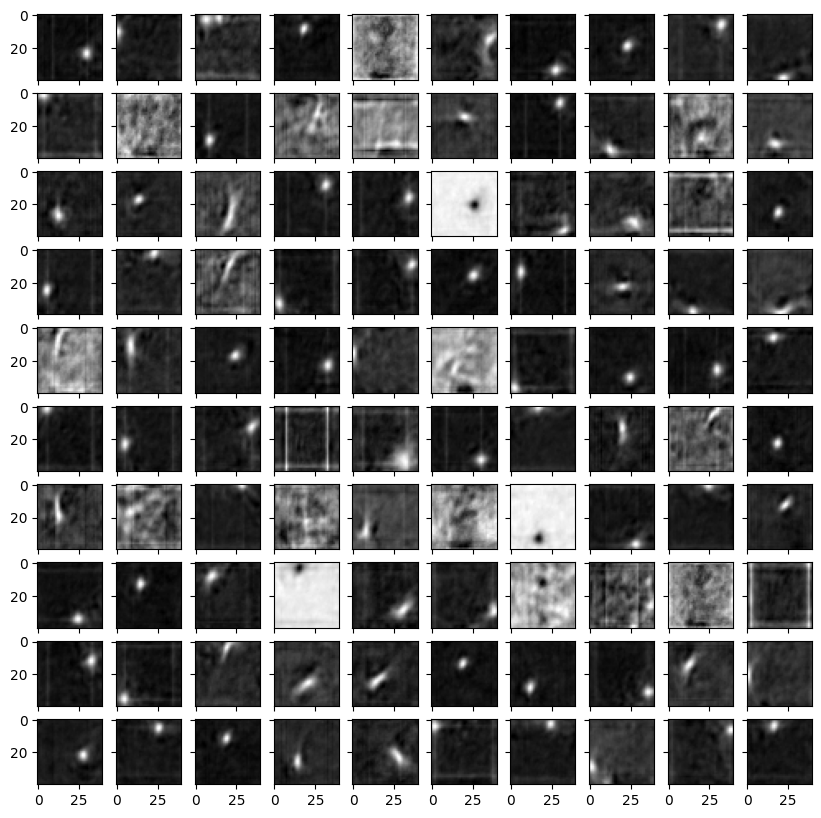

In [14]:
w1 = get_weights(dbn, layer=0)
w2 = get_weights(dbn, layer=1)

w1 = apply_threshold(w1, 0.01)
w2 = apply_threshold(w2, 0.01)

w_product = (w1 @ w2)  # here we do the projection
w_product = apply_threshold(w_product, 0.01)
w_product = apply_min_max_scaler(w_product)

plot_layer_receptive_fields(w_product.T)

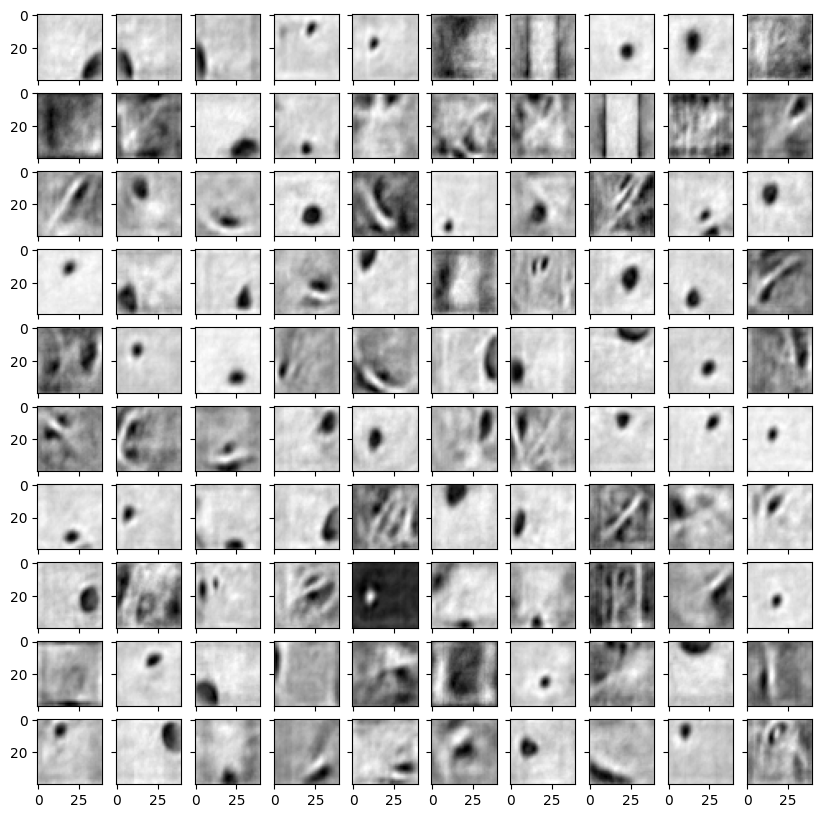

In [15]:
w1 = get_weights(dbn, layer=0)
w2 = get_weights(dbn, layer=1)
w3 = get_weights(dbn, layer=2)

w1 = apply_threshold(w1, 0.01)
w2 = apply_threshold(w2, 0.01)
w3 = apply_threshold(w3, 0.01)

w_product_12 = (w1 @ w2)  # here we do the projection
w_product_23 = (w_product_12 @ w3)  # here we do the projection
w_product_23 = apply_threshold(w_product_23, 0.1)
w_product_23 = apply_min_max_scaler(w_product_23)

plot_layer_receptive_fields(w_product_23.T)

First Layer Visualization: the first layer filters capture basic, localized features such as edges, corners, and simple shapes.

Second Layer Visualization: the receptive fields of the second layer show mostly dark areas with some scattered points.

Third Layer Visualization:  the network shifts from detecting tiny, isolated fragments to capturing broader, more global patterns that represent the general structure of an object. Here more defined shapes like the ones seen during the labs are not visible, but it is possible to notice that they are less focused compared to the ones in the first layer


In [16]:
def get_kth_layer_repr(input, k, device):
  flattened_input = input.view((input.shape[0], -1)).type(torch.FloatTensor).to(device)
  hidden_repr, __ = dbn.rbm_layers[k].to_hidden(flattened_input)  # here we access the RBM object
  return hidden_repr

def get_hidden_reprs_matrix(hidden_repr, df):
    """
    Takes the output from get_kth_layer_repr and
    uses df_train labels to compute class means.
    """
    #convert tensor to numpy for processing
    hidden_repr_np = hidden_repr.cpu().detach().numpy()
    labels = df['label'].values

    #create a temporary DataFrame to use groupby for speed
    h_df = pd.DataFrame(hidden_repr_np)
    h_df['label'] = labels

    #calculate means for all 11 classes (sorted by label 0-10)
    return h_df.groupby('label').mean().sort_index().values

def plot_dendrogram(mean_repr_matrix, labels, title=""):
  fig, ax = plt.subplots(figsize=(12, 5))
  linkage = cluster.hierarchy.linkage(mean_repr_matrix, method="complete")
  dendrogram = cluster.hierarchy.dendrogram(linkage, labels=labels)
  ax.set_title(title)
  plt.show()

In [17]:
hidden_repr_1 = get_kth_layer_repr(train_input, 0, device)
hidden_repr_2 = get_kth_layer_repr(hidden_repr_1, 1, device)
hidden_repr_3 = get_kth_layer_repr(hidden_repr_2, 2, device)

In [18]:
def get_mask(label):
  labels = train_target.cpu().numpy()
  return labels == label

def get_label_to_mean_hidd_repr(hidden_repr):
  hidden_repr_np = hidden_repr.cpu().numpy()
  return {
    label: hidden_repr_np[get_mask(label)].mean(axis=0)
    for label in range(27)
  }

def get_hidden_reprs_matrix(hidden_repr):
  label_to_mean_hidd_repr = get_label_to_mean_hidd_repr(hidden_repr)
  return np.concatenate(
    [np.expand_dims(label_to_mean_hidd_repr[label], axis=0)
    for label in range(27)])

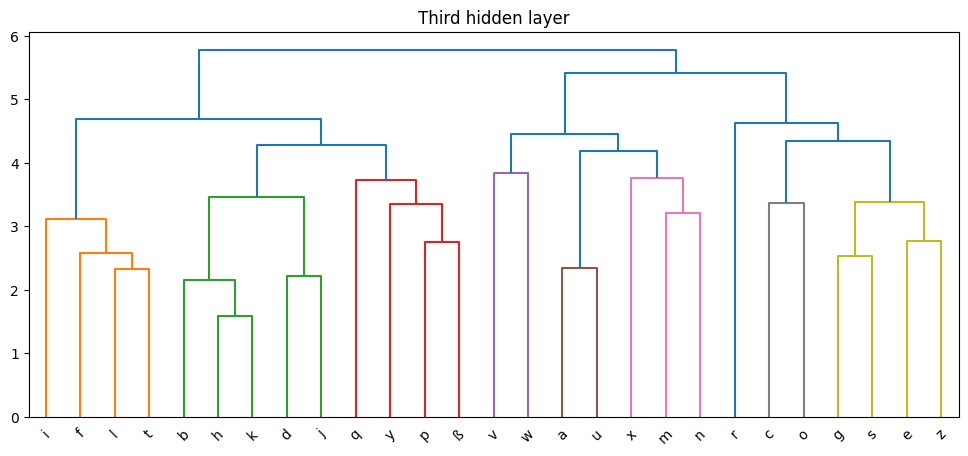

In [19]:
mean_hidd_repr_matrix_3 = get_hidden_reprs_matrix(hidden_repr_3)

#number of mean hidden representations (rows) from the third hidden layer
num_rows = mean_hidd_repr_matrix_3.shape[0]
#matching number of class labels to correspond with the hidden representations
matched_labels = classes[:num_rows]

#plot
plot_dendrogram(mean_hidd_repr_matrix_3, matched_labels, "Third hidden layer")

The dendrogram visualizes the hierarchical clustering of the class means extracted from the third hidden layer, revealing how the model perceives structural relationships between different characters.

For instance, characters with shared structural traits are positioned on adjacent branches (as somewhat expected), such as the pairing of "m" and "n", or the grouping of "p" and "ß" which likely share a vertical stem and rounded loop configuration or "i", "f", "l" and "t".

## **Linear read-outs**

To evaluate the quality of the representations learned by the Deep Belief Network, linear readout classifiers are applied to the activations of different hidden layers. A linear readout consists of a simple linear classifier trained on the fixed features extracted from a given layer, without modifying the internal weights of the DBN.

This approach allows to assess how easily letter categories can be separated at each level of the hierarchy. If a linear classifier achieves higher accuracy when trained on deeper-layer activations, it suggests that the corresponding representations are more "disentangled" providing a quantitative measure of how hierarchical learning shapes the structure of the internal feature space.

In [20]:
def train_linear(linear, hidden_reprs, targets):
  optimizer = torch.optim.SGD(linear.parameters(), lr=0.05)
  loss_fn = torch.nn.CrossEntropyLoss()
  epochs = 1000

  targets = targets.to(device)

  for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = linear(hidden_reprs)

    # CrossEntropyLoss expects (N, C) for predictions and (N) for targets
    loss = loss_fn(predictions, targets)

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
      print("epoch : {:3d}/{}, loss = {:.4f}".format(epoch + 1, epochs, loss.item()))

In [21]:
#maximum label in your dataset
max_label = train_target.max().item()

#required output neurons
required_output_size = max_label + 1

#Linear Model
class LinearModel(torch.nn.Module):
    def __init__(self, layer_size, num_classes):
        super().__init__()
        self.linear = torch.nn.Linear(layer_size, num_classes)

    def forward(self, x):
        return self.linear(x)

#layer 1
layer_size_0 = dbn.rbm_layers[0].W.shape[1]
linear1 = LinearModel(layer_size_0, required_output_size).to(device)

#layer 2
layer_size_1 = dbn.rbm_layers[1].W.shape[1]
linear2 = LinearModel(layer_size_1, required_output_size).to(device)

#layer 3
layer_size_2 = dbn.rbm_layers[2].W.shape[1]
linear3 = LinearModel(layer_size_2, required_output_size).to(device)

In [22]:
#mapping from each unique label (character) to a unique integer index
label_to_idx = {ch: i for i, ch in enumerate(sorted(np.unique(y_train)))}
vectorize_map = np.vectorize(lambda x: label_to_idx[x])

#apply the mapping to the training and test labels
y_train_idx = vectorize_map(y_train)
y_test_idx  = vectorize_map(y_test)

#convert the training features to a PyTorch tensor of type float32
train_input = torch.tensor(X_train.values.astype(np.float32))

#convert the training labels to a PyTorch tensor of type long (required for classification loss functions)
train_target = torch.tensor(y_train_idx, dtype=torch.long)

#convert the test features to a PyTorch tensor of type float32
test_input = torch.tensor(X_test.values.astype(np.float32))

#convert the test labels to a PyTorch tensor of type long
test_target = torch.tensor(y_test_idx, dtype=torch.long)

In [23]:
print('linear 1:')
train_linear(linear1, hidden_repr_1, train_target)
print('linear 2:')
train_linear(linear2, hidden_repr_2, train_target)
print('linear 3:')
train_linear(linear3, hidden_repr_3, train_target)

linear 1:
epoch :   1/1000, loss = 3.3239
epoch : 101/1000, loss = 2.3326
epoch : 201/1000, loss = 1.8832
epoch : 301/1000, loss = 1.6548
epoch : 401/1000, loss = 1.5206
epoch : 501/1000, loss = 1.4317
epoch : 601/1000, loss = 1.3676
epoch : 701/1000, loss = 1.3184
epoch : 801/1000, loss = 1.2789
epoch : 901/1000, loss = 1.2463
linear 2:
epoch :   1/1000, loss = 3.3085
epoch : 101/1000, loss = 2.2081
epoch : 201/1000, loss = 1.8059
epoch : 301/1000, loss = 1.6120
epoch : 401/1000, loss = 1.4971
epoch : 501/1000, loss = 1.4194
epoch : 601/1000, loss = 1.3622
epoch : 701/1000, loss = 1.3177
epoch : 801/1000, loss = 1.2816
epoch : 901/1000, loss = 1.2516
linear 3:
epoch :   1/1000, loss = 3.3319
epoch : 101/1000, loss = 2.2536
epoch : 201/1000, loss = 1.8079
epoch : 301/1000, loss = 1.5919
epoch : 401/1000, loss = 1.4665
epoch : 501/1000, loss = 1.3832
epoch : 601/1000, loss = 1.3225
epoch : 701/1000, loss = 1.2756
epoch : 801/1000, loss = 1.2377
epoch : 901/1000, loss = 1.2061


In [24]:
hidden_repr_1_test = get_kth_layer_repr(test_input, 0, device)
hidden_repr_2_test = get_kth_layer_repr(hidden_repr_1_test, 1, device)
hidden_repr_3_test = get_kth_layer_repr(hidden_repr_2_test, 2, device)

In [25]:
#compute the classifier predictions
predictions_test1 = linear1(hidden_repr_1_test)
predictions_test2 = linear2(hidden_repr_2_test)
predictions_test3 = linear3(hidden_repr_3_test)

In [26]:
def compute_accuracy(predictions_test, targets):
    predictions_indices = predictions_test.max(axis=1).indices
    #ensure targets are on the same device as predictions
    targets = targets.to(predictions_indices.device)
    accuracy = (predictions_indices == targets).sum() / len(targets)
    return accuracy.item()

#compute accuracy
acc1 = compute_accuracy(predictions_test1, test_target)
acc2 = compute_accuracy(predictions_test2, test_target)
acc3 = compute_accuracy(predictions_test3, test_target)

#print results
print(f"Accuracy Layer 1: {acc1:.4f} ({acc1*100:.2f}%)")
print(f"Accuracy Layer 2: {acc2:.4f} ({acc2*100:.2f}%)")
print(f"Accuracy Layer 3: {acc3:.4f} ({acc3*100:.2f}%)")

Accuracy Layer 1: 0.6959 (69.59%)
Accuracy Layer 2: 0.6973 (69.73%)
Accuracy Layer 3: 0.7047 (70.47%)


The DBN achieves about 70% accuracy with a slight improvement across layers, but the performance gain is modest, suggesting limited additional refinement with depth and indicating that even the first layer captures useful features for distinguishing the characters.

The overall accuracy might be constrained by visual similarity between letters.

### **Error analysis**

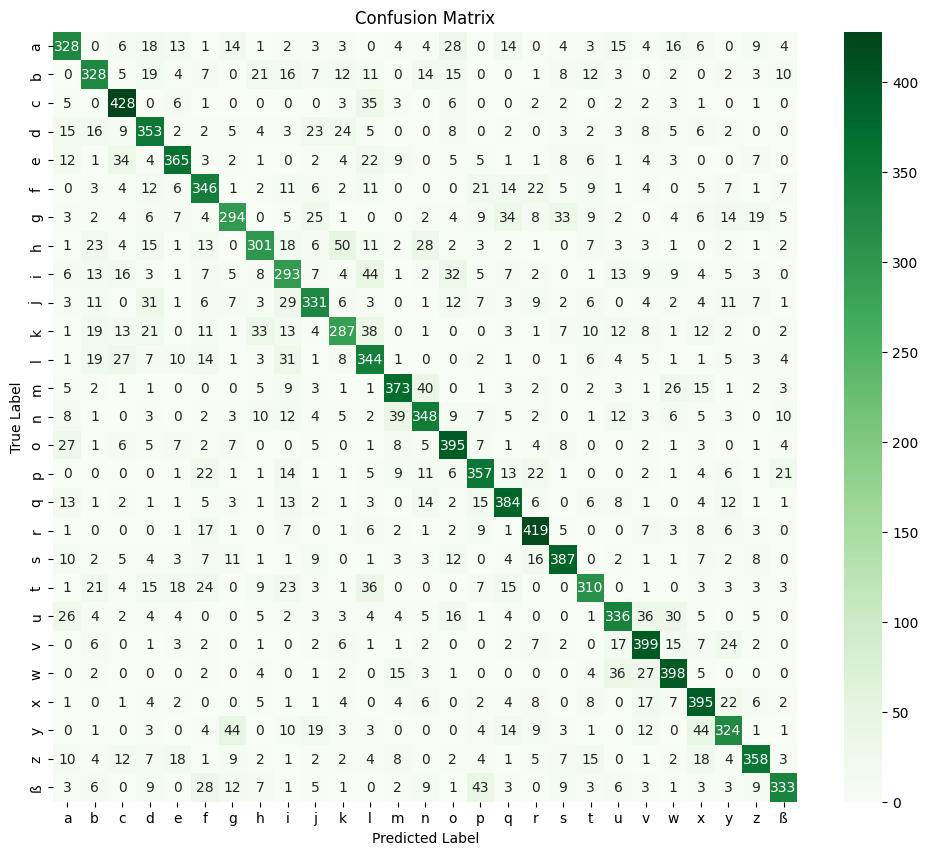

In [27]:
#create reverse mapping index -> letter
idx_to_label = {i: ch for ch, i in label_to_idx.items()}
class_labels = [idx_to_label[i] for i in range(len(idx_to_label))]

#get predictions from the final model
linear3.eval()
with torch.no_grad():
    test_logits = linear3(hidden_repr_3_test)
    predicted_labels = test_logits.argmax(dim=1).cpu().numpy()
    true_labels = test_target.cpu().numpy()

#confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

#heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=True, xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix visualizes the classification performance of the model across the 27 categories of the German alphabet, where a strong dark green diagonal indicates that the majority of characters are being correctly identified.

While the overall accuracy is robust, the subtle off-diagonal green markers reveal specific areas of structural confusion where the model misidentifies characters with similar geometric traits. For instance, "t" is confused with other letters like "b", "d", "f", "l" (all of them have the similar long stem), and that somewhat mirrors the visual grouping seen in the third-layer dendrogram.

Despite these overlaps, the high density of correct predictions along the diagonal confirms that the Deep Belief Network has effectively learned to differentiate the unique topological features required for high-fidelity character recognition.

### **Robustness to noise**

Robustness to noise refers to a model’s ability to maintain good performance when its inputs are corrupted or degraded. In image classification, this means that, even if the input images are partially noisy, distorted, or altered, the model should still correctly recognize the characters.

In [28]:
def inject_noise(df, noise_level):
  random_gaussian_tensor = torch.randn(df.shape)/6.6 + .6
  probability_tensor = torch.ones(df.shape)*noise_level
  mask_tensor = torch.bernoulli(probability_tensor)
  return df - mask_tensor * df + mask_tensor * random_gaussian_tensor

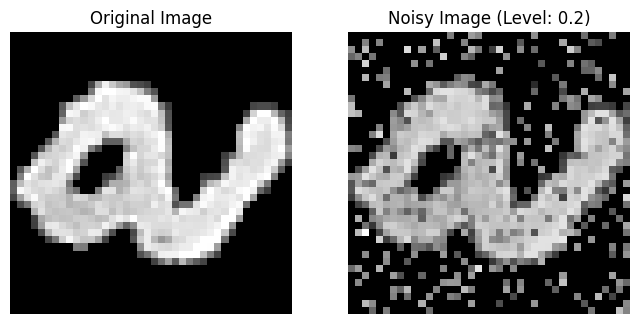

In [29]:
original_img = train_input[0].unsqueeze(0)

#noise
noise_level = 0.2
noisy_img = inject_noise(original_img, noise_level)

#side by side plots
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

#original
axes[0].imshow(original_img.reshape(40, 40).cpu().numpy(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

#noisy
axes[1].imshow(noisy_img.reshape(40, 40).cpu().numpy(), cmap='gray')
axes[1].set_title(f"Noisy Image (Level: {noise_level})")
axes[1].axis('off')

plt.show()

^^ Above an example of image before and after injecting noise

Running robustness check...
Noise 0.00 -> L1: 0.696 | L2: 0.697 | L3: 0.705
Noise 0.10 -> L1: 0.510 | L2: 0.620 | L3: 0.554
Noise 0.20 -> L1: 0.276 | L2: 0.280 | L3: 0.249
Noise 0.30 -> L1: 0.173 | L2: 0.141 | L3: 0.152
Noise 0.40 -> L1: 0.107 | L2: 0.075 | L3: 0.097
Noise 0.50 -> L1: 0.072 | L2: 0.051 | L3: 0.070
Noise 0.75 -> L1: 0.039 | L2: 0.037 | L3: 0.038
Noise 1.00 -> L1: 0.037 | L2: 0.037 | L3: 0.037


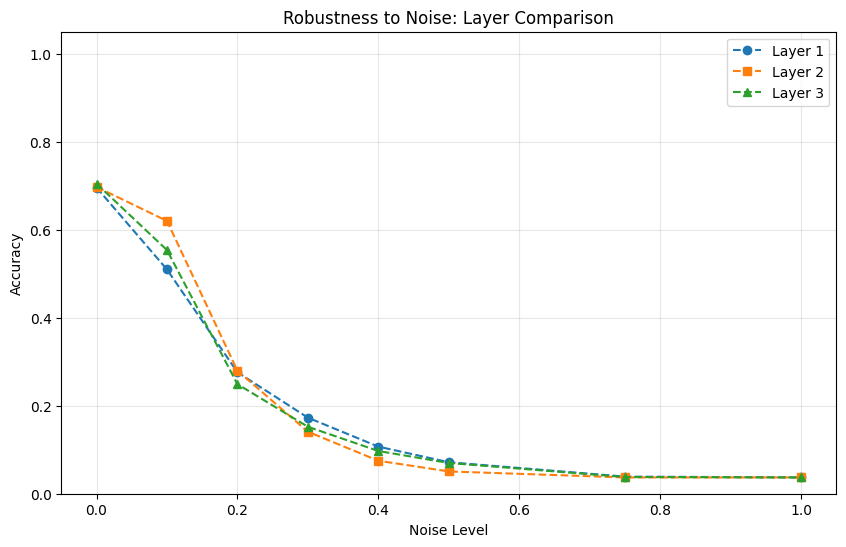

In [30]:
#evaluation
def get_accuracies_at_noise_level(noise_level):
    noisy_input = inject_noise(test_input.clone(), noise_level)
    h1 = get_kth_layer_repr(noisy_input, 0, device)
    linear1.eval()
    with torch.no_grad():
        preds1 = linear1(h1)
        acc1 = compute_accuracy(preds1, test_target)

    h2 = get_kth_layer_repr(h1, 1, device)
    linear2.eval()
    with torch.no_grad():
        preds2 = linear2(h2)
        acc2 = compute_accuracy(preds2, test_target)

    h3 = get_kth_layer_repr(h2, 2, device)
    linear3.eval()
    with torch.no_grad():
        preds3 = linear3(h3)
        acc3 = compute_accuracy(preds3, test_target)

    return acc1, acc2, acc3

#plot function
def plot_noise_robustness_curves(noise_levels):
    acc_list_l1 = []
    acc_list_l2 = []
    acc_list_l3 = []

    print("Running robustness check...")
    for noise in noise_levels:
        a1, a2, a3 = get_accuracies_at_noise_level(noise)
        acc_list_l1.append(a1)
        acc_list_l2.append(a2)
        acc_list_l3.append(a3)
        print(f"Noise {noise:.2f} -> L1: {a1:.3f} | L2: {a2:.3f} | L3: {a3:.3f}")

    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot all 3 curves
    plt.plot(noise_levels, acc_list_l1, label="Layer 1", marker='o', linestyle='--')
    plt.plot(noise_levels, acc_list_l2, label="Layer 2", marker='s', linestyle='--')
    plt.plot(noise_levels, acc_list_l3, label="Layer 3", marker='^', linestyle='--')

    plt.title("Robustness to Noise: Layer Comparison")
    plt.xlabel("Noise Level")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

#noise levels
noise_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]
plot_noise_robustness_curves(noise_range)

The noise levels tested in this evaluation are: 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, and 1.0. The plot illustrates how the classification accuracy of the DBN degrades as the intensity of the noise increases across its three hidden layers.

All layers start with a baseline accuracy of approximately 70%, and layer 2, indicated by the orange dashed line, proves to be the most robust, maintaining significantly higher accuracy.

As the noise level surpasses 0.6, the accuracy for all layers converges toward zero, indicating that the noise eventually wipe out the structure required for the model's internal representations to function effectively.

## **Fast Gradient Sign Adversarial Attack**

In [31]:
def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon*sign_data_grad
    # Adding clipping to maintain [0,1] range
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    # Return the perturbed image
    return perturbed_image

In [32]:
class DBNWithReadOut(torch.nn.Module):
    def __init__(self, dbn_mnist, readout):
        super().__init__()
        self.readout = readout
        self.readout_level = 2
        self.dbn_mnist = dbn_mnist
        self._require_grad()

    def _require_grad(self):
      for rbm in self.dbn_mnist.rbm_layers:
        rbm.W.requires_grad_()
        rbm.h_bias.requires_grad_()

    def forward(self, image):
      """This forward pass uses probabilities instead of samples as RBM activations
       to backpropagate the gradient"""
      p_v = image
      hidden_states = []
      for rbm in self.dbn_mnist.rbm_layers:
        p_v = p_v.view((p_v.shape[0], -1))  # flatten
        p_v, v = rbm(p_v)
        hidden_states.append(p_v)
      return self.readout.forward(hidden_states[self.readout_level])

dbn_with_readout = DBNWithReadOut(dbn, linear3)

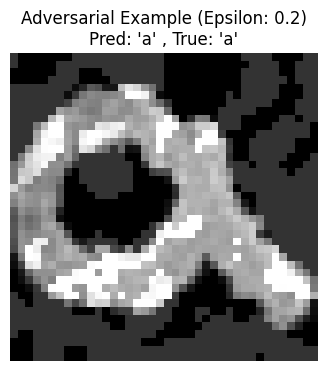

In [33]:
test_sample_idx=24
test_image = test_input[test_sample_idx].unsqueeze(0).clone().detach().to(device).requires_grad_(True)

#label
test_image_label = test_target[test_sample_idx].unsqueeze(0).to(device)

model_outputs = dbn_with_readout(test_image)

#loss
loss_value = torch.nn.functional.cross_entropy(model_outputs, test_image_label)
dbn_with_readout.zero_grad()
loss_value.backward()

#gradients
image_grad = test_image.grad.data

#attack and visualization
epsilon = 0.2
perturbed_image = fgsm_attack(test_image, epsilon, image_grad)

#prediction of the attacked image
output_perturbed = dbn_with_readout(perturbed_image)
final_pred_idx = torch.argmax(output_perturbed).item()
predicted_label = classes[final_pred_idx]
true_label = classes[test_target[test_sample_idx].item()]

#plot
perturbed_image_np = perturbed_image.detach().cpu().numpy()
plt.figure(figsize=(4,4))
plt.imshow(perturbed_image_np.reshape(40, 40), cmap='gray')
plt.title(f"Adversarial Example (Epsilon: {epsilon})\nPred: '{predicted_label}' , True: '{true_label}'")
plt.axis('off')
plt.show()

And here's an exaple of attack with successful defense: the input is subjected to a perturbation with an epsilon of 0.2 and the model in this case is able to correcctly identify the character 'a', matching the ground truth label.

In [34]:
def test_robustness_to_attack(model, device, test_loader, epsilon, num_steps=0, verbose=True):
    correct = 0  # count number of correct classifications
    print_reconstruction = num_steps > 0  # if we request for top-down reconstruction, show the resulting image

    for data, target in tqdm(test_loader):
        data, target = data.to(device), target.to(device)
        data = data.reshape(-1, 1600)
        data.requires_grad = True  # we need to get the gradient to perform the attack

        output = model.forward(data)  # forward pass through the model

        init_pred = torch.argmax(output)  # prediction before the attack

        if (print_reconstruction and verbose):
          print("\nHere's the original sample:\n")
          plt.imshow(data[0].detach().to('cpu').numpy().reshape(40,40))
          plt.show()

        loss_value = torch.nn.functional.cross_entropy(output, target) # get loss value
        model.zero_grad()
        loss_value.backward()
        data_grad = data.grad.data  # collect the gradient with respect to the input data
        perturbed_data = fgsm_attack(data, epsilon, data_grad)  # call the attack function previously defined

        if (print_reconstruction and verbose):
            print("\nHere's a perturbed sample:\n")
            plt.imshow(perturbed_data[0].detach().to('cpu').numpy().reshape(40,40))
            plt.show()

        # If requested, reconstruct the input iterating bottom-up and top-down sampling
        if num_steps > 0:
            for __ in range(0, num_steps):
                perturbed_data, __ = model.dbn_mnist.reconstruct(perturbed_data)
            if (print_reconstruction and verbose):
                print(f"\nHere's what a {num_steps}-steps reconstructed sample looks like:\n")
                plt.imshow(perturbed_data[0].detach().to('cpu').numpy().reshape(40,40))
                plt.show()
                print_reconstruction = False

        # Re-classify the perturbed image
        output = model(perturbed_data)

        # Check for success
        # get the index of the max element in the output
        final_pred = output.max(1, keepdim=True)[1]
        final_pred = output.argmax(-1)
        correct += (final_pred == target).sum()

    # Calculate final accuracy for this epsilon
    final_acc = correct/float(len(test_loader.sampler))
    print("\nEpsilon: {}\nTest Accuracy: {:.2f}%\n".format(epsilon, final_acc*100))

    return final_acc.item()

In [35]:
epsilon_values = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

def test_epsilon_values_effect(model, n_steps):
  accuracies = list()

  for eps in epsilon_values:
      acc = test_robustness_to_attack(model, device, test_loader, eps, num_steps=n_steps, verbose=False)  # set verbose to False to avoid displaying too many images
      accuracies.append(acc)

  return accuracies

In [36]:
#TensorDataset for training and test sets
train_dataset = TensorDataset(train_input, train_target)
test_dataset  = TensorDataset(test_input, test_target)

#DataLoader
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=100, shuffle=True)

In [37]:
accuracies_dbn_0 = test_epsilon_values_effect(dbn_with_readout, n_steps=0)
print("DBN 1 steps")
accuracies_dbn_1 = test_epsilon_values_effect(dbn_with_readout, n_steps=1)
print("DBN 2 steps")
accuracies_dbn_2 = test_epsilon_values_effect(dbn_with_readout, n_steps=2)

100%|██████████| 135/135 [00:00<00:00, 151.94it/s]



Epsilon: 0
Test Accuracy: 70.47%



100%|██████████| 135/135 [00:00<00:00, 153.35it/s]



Epsilon: 0.05
Test Accuracy: 52.34%



100%|██████████| 135/135 [00:01<00:00, 129.58it/s]


...


Epsilon: 0.2
Test Accuracy: 6.37%



100%|██████████| 135/135 [00:02<00:00, 66.96it/s]



Epsilon: 0.25
Test Accuracy: 3.15%



100%|██████████| 135/135 [00:01<00:00, 72.41it/s]


Epsilon: 0.3
Test Accuracy: 1.82%



<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-3970482353.py:7: SyntaxWarning: invalid escape sequence '\e'
  __ = ax.set_xlabel("Strength of adversarial attack ($\epsilon$)")


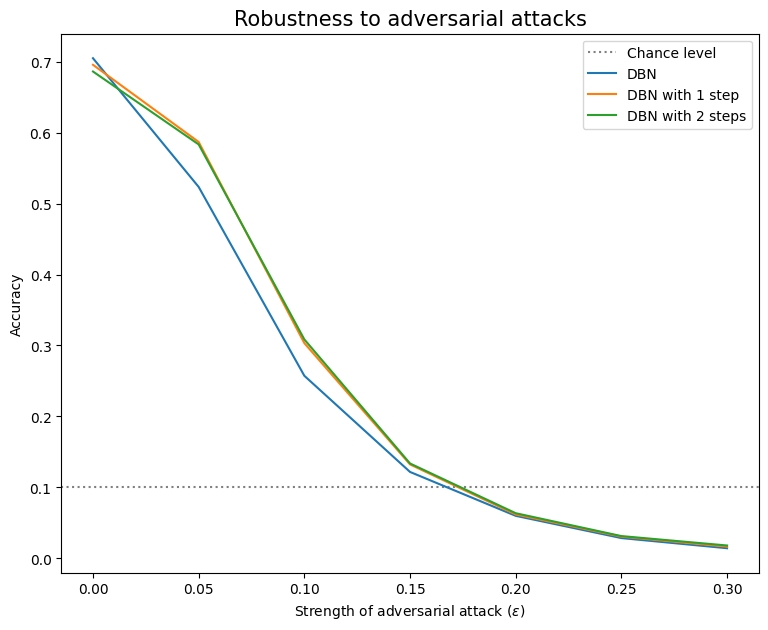

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7), sharey=True)

__ = ax.axhline(0.1, color='gray', linestyle=':')
__ = ax.plot(epsilon_values, accuracies_dbn_0)
__ = ax.plot(epsilon_values, accuracies_dbn_1)
__ = ax.plot(epsilon_values, accuracies_dbn_2)
__ = ax.set_xlabel("Strength of adversarial attack ($\epsilon$)")
__ = ax.set_ylabel("Accuracy")
__ = ax.set_title("Robustness to adversarial attacks", {'fontsize': 15})
__ = ax.legend(["Chance level", "DBN", "DBN with 1 step", "DBN with 2 steps"])

The graph illustrates the robustness of the DBN to adversarial attacks by plotting classification accuracy against increasing levels of perturbations. As the strength of the attack increases from 0.0 to 0.3, all model configurations experience a significant decline in accuracy, eventually converging toward the chance level once the adversarial noise overwhelms the learned structural features.

The results clearly demonstrate that the DBNs utilizing generative reconstruction, using either 1 step or 2 steps, consistently maintain higher accuracy compared to the standard DBN in the mid-range of attack strengths.

## **Conclusions**

The project trained a DBN with the German lowercase character dataset (a–z and ß) and evaluated its learned representations using linear readout and clustering analyses. The results show that the network successfully develops increasingly structured internal representations, with the deepest hidden layer yielding the best linear separability, indicating that the DBN is able to extract meaningful and progressively more abstract features from 40×40 handwritten character images.

However, the error analysis and confusion matrix reveal that the model performs unevenly across certain letters, with systematic confusions between visually similar characters and, for some classes, the model may rely more on superficial or dataset-specific visual cues rather than fully generalized structural features. The feature visualizations further support this observation: while many hidden units capture clear edge- and stroke-based patterns, some appear highly specialized, potentially reflecting memorization of recurring shapes instead of robust character abstractions.

Overall, the DBN demonstrates solid representational learning and reasonable classification performance, but the analysis highlights limitations in generalization, particularly for visually overlapping letter categories.
